<a href="https://colab.research.google.com/github/divya374r1/Neural-Network-and-Deep-Learning/blob/main/Plant_disease_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload kaggle.json file


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:02<00:00, 237MB/s]

Dataset Extracted!
Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Training started...
Epoch 1/2
517/517 ━━━━━━━━━━━━━━━━━━━━ 527s 1s/step - accuracy: 0.6612 - loss: 1.0534 - val_accuracy: 0.7972 - val_loss: 0.5964
Epoch 2/2
517/517 ━━━━━━━━━━━━━━━━━━━━ 523s 1s/step - accuracy: 0.8412 - loss: 0.4635 - val_accuracy: 0.8634 - val_loss: 0.4263


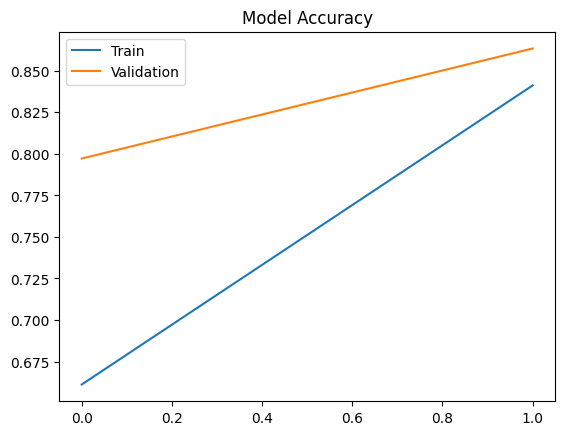

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


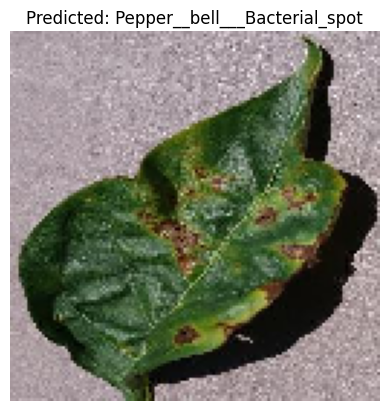

Prediction: Pepper__bell___Bacterial_spot

✅ DONE: Model trained + prediction shown successfully!


In [2]:
# ============================================================
# Plant Disease Detection using CNN + Prediction (FINAL CODE)
# ============================================================

# Step 1: Install Kaggle
!pip install kaggle -q

# Step 2: Upload kaggle.json
from google.colab import files
print("Upload kaggle.json file")
files.upload()

# Step 3: Setup Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 4: Download Dataset
print("Downloading dataset...")
!kaggle datasets download -d emmarex/plantdisease

# Step 5: Extract Dataset
import zipfile

with zipfile.ZipFile("plantdisease.zip", 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset Extracted!")

# Step 6: Set Dataset Path
dataset_path = "/content/PlantVillage"

# Step 7: Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
import os

# Step 8: Data Preprocessing
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Step 9: Build CNN Model
model = models.Sequential([
    layers.Input(shape=(128,128,3)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(train.num_classes,activation='softmax')
])

# Step 10: Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Step 11: Train Model (FAST)
print("Training started...")
history = model.fit(train, validation_data=val, epochs=2)

# Step 12: Plot Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Model Accuracy")
plt.show()

# ============================================================
# Step 13: Prediction (IMPORTANT OUTPUT)
# ============================================================

# Get class names
class_names = list(train.class_indices.keys())

# Pick sample image from dataset
sample_class = class_names[0]
sample_dir = os.path.join(dataset_path, sample_class)
sample_image = os.listdir(sample_dir)[0]
img_path = os.path.join(sample_dir, sample_image)

# Load image
img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Predict
prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

# Show result
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {predicted_class}")
plt.show()

print("Prediction:", predicted_class)

print("\n✅ DONE: Model trained + prediction shown successfully!")